In [ ]:
import os, random
import numpy as np
import torch
import lightning as L
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import yfinance as yf
from torchmetrics.functional import mean_absolute_error, mean_squared_error
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, GroupNormalizer 
from pytorch_forecasting.metrics import QuantileLoss
import matplotlib.pyplot as plt





print("PyTorch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("CUDA disponibile:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("cuDNN:", torch.backends.cudnn.version())


PyTorch: 2.5.1
torch.version.cuda: 12.4
CUDA disponibile: True
Device: NVIDIA GeForce RTX 4050 Laptop GPU
cuDNN: 90100


In [ ]:


def set_seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

# DATA

In [3]:
return_data = pd.read_excel("return_data.xlsx")
return_data["Date"] = pd.to_datetime(return_data["Date"])
return_data = return_data.set_index("Date")

data_price = pd.read_excel("price_data.xlsx")
data_price["Date"] = pd.to_datetime(data_price["Date"])
data_price = data_price.set_index("Date")

In [4]:
return_data.columns = return_data.columns.str.replace("_Price", "", regex=False)

In [5]:
return_data["time_idx"] = np.arange(len(return_data), dtype=np.int64)
return_data["group_id"] = "GRP"

return_data["dow"] = return_data.index.dayofweek.astype(str)  # DAY OF WEEK
return_data["dom"] = return_data.index.day.astype(str)        # DAY OF MONTH
return_data["woy"] = return_data.index.isocalendar().week.astype(int).astype(str)  # WEEK OF YEAR
return_data["month"] = return_data.index.month.astype(str)

## Required DataFrame structure for using a Temporal Fusion Transformer (TFT) in **PyTorch Forecasting**

In PyTorch Forecasting, TFT models are typically trained via a `TimeSeriesDataSet`, which expects your data in **“long” (tidy) format**: **one row per timestamp per entity**. Concretely, *each row must be uniquely identifiable by*:

- **`time_idx`**: an **integer** time index column that defines the temporal order
- **`group_id` / `group_ids`**: one or more columns that identify **which time series** the row belongs to  
  (the dataset can contain many parallel series)

This is the key requirement: **(group_ids, time_idx) → one observation row**. 


---

## `time_idx`: meaning, role, and best practices

### What it is
- `time_idx` is an **integer-typed** column used to determine the **sequence order** of samples. 

### What it is *not*
- It does **not** need to be an actual timestamp (like `datetime`). If you have datetimes, you usually convert them into an integer index (  month number, day number, etc.).

### Increment rule
- If there are **no missing observations**, `time_idx` should typically increase by **+1** at each step within a series.   
- If you *do* have missing steps, you can still keep the index consistent (  skip values), but the main goal is that `time_idx` correctly encodes ordering and spacing.

### Why this code works
```python
return_data["time_idx"] = np.arange(len(return_data), dtype=np.int64)
```
This creates a clean integer index $0, 1, 2, ...$ for a single continuous series where each row is the next time step.


## The role of `group_id` (or `group_ids`) in Temporal Fusion Transformer (TFT)

When using the Temporal Fusion Transformer implemented in [*PyTorch Forecasting*](https://pytorch-forecasting.readthedocs.io/en/v1.4.0/api/pytorch_forecasting.data.timeseries._timeseries.TimeSeriesDataSet.html), the dataset must be organized so that each row is uniquely identified by:

- `time_idx` → integer time index  
- `group_ids` → one or more columns identifying **which time series entity** the row belongs to  

Formally, each observation is uniquely defined by:

(group_ids, time_idx)

This structure is required by the `TimeSeriesDataSet` class in PyTorch Forecasting. Even if you have only one single time series, you must still provide a group identifier column.

---

## Why `group_id` is mandatory

`group_ids` are required because the dataset object:

1. **Separates different time series instances**
2. Generates encoder/decoder training windows per series
3. Ensures that temporal samples are never mixed across different entities

The documentation explicitly states that if only one time series is present, a constant group id column must still be provided.

So `group_id` must always exist when using `TimeSeriesDataSet`, even for a single-series problem.

---

## Case 1 — Single series (only one group value)

Example structure:

| group_id | time_idx | target |
|----------|----------|--------|
| GRP      | 0        | 10.0   |
| GRP      | 1        | 11.2   |
| GRP      | 2        | 10.8   |

Here:

- All rows share the same `group_id`
- The dataset contains only one time series
- The model behaves like a classical univariate forecasting setup

Even though there is only one series, `group_id` is still required because the dataset API is designed for the general multi-series case.

In this scenario:
- There is **no cross-entity information sharing**
- The model trains only on temporal dynamics of that single entity

---

## Case 2 — Multiple group values (panel / longitudinal data)

Example:

| group_id | time_idx | target |
|----------|----------|--------|
| A        | 0        | 10.0   |
| A        | 1        | 11.2   |
| B        | 0        |  7.1   |
| B        | 1        |  6.9   |

Here:

- Each unique `group_id` defines a different time series entity
- The model is trained on **multiple related series simultaneously**
- This setup is known as **panel data forecasting** (or multi-series / global forecasting)

The TFT in this configuration learns:

- Shared temporal patterns across all entities
- Entity-specific behavior via embeddings of categorical identifiers (if included as static categorical features)

This is NOT the same as “multivariate target forecasting”. Instead, it is:

Many univariate series  
→ trained with one global model  
→ sharing statistical strength across entities  

---

## Composite `group_ids` (hierarchical panel data)

You can also use multiple columns to define a series identity.

Example:

| store | product | time_idx | sales |
|-------|---------|----------|-------|
| S1    | P10     | 0        | 12.0  |
| S1    | P10     | 1        | 13.5  |
| S2    | P10     | 0        |  8.0  |

If `group_ids = ["store", "product"]`, then each (store, product) pair defines one independent time series.

This enables:

- Hierarchical panel modeling
- Learning shared structure across stores
- Learning shared structure across products
- Entity-level embeddings for each identifier

---

## How TFT actually uses `group_id`

There are two conceptual levels:

### 1) Dataset-level usage (always active)

`group_ids` are used to:

- Split the dataframe into separate time series
- Generate sliding windows per entity
- Prevent mixing of different entities inside the same training sample

This functionality is mandatory and independent of the neural architecture.

---

### 2) Model-level usage (if configured as categorical feature)

If you include the group identifier columns as **static categorical features**, TFT:

- Learns an embedding vector per group
- Conditions the temporal dynamics on that embedding
- Allows entity-specific scaling, seasonality, or behavior

This mechanism is consistent with the original TFT paper, where static covariates are encoded and used to condition temporal processing.

---

## Panel vs Multivariate — Important distinction

`group_id` implies **panel (multi-series) forecasting**, not multivariate target forecasting.

Panel setup:
- One target variable
- Many entities (many `group_id` values)
- One global model shared across series

Multivariate target setup:
- Multiple target variables predicted simultaneously at the same timestamp
- This is configured separately via multiple target columns

Therefore:

`group_id` manages entity identity  
It does NOT automatically make the problem multivariate  



In [6]:
train = return_data.loc[:'2024-12-31']
test  = return_data.loc['2025-01-01':]
train_price = data_price.loc[:'2024-12-31']
test_price  = data_price.loc['2025-01-01':]


initial_price = train_price["Bitcoin_Price"].iloc[-1] 


In [7]:
def returns_to_prices(returns_df: pd.DataFrame, initial_price: float) -> pd.DataFrame:
    """
    Convert a DataFrame of log returns (in %) into price levels,
    given a single initial price valid for all columns.
    
    Parameters
    ----------
    returns_df : pd.DataFrame
        DataFrame with log returns * 100 (percent log returns).
        Index should be dates, columns are different forecast scenarios.
    initial_price : float
        The known price at the last observed date (e.g. 2024-12-31).
    
    Returns
    -------
    pd.DataFrame
        DataFrame with reconstructed price series.
    """
   
    growth_factors = np.exp(returns_df / 100.0)
    

    cum_growth = growth_factors.cumprod()
    

    prices = initial_price * cum_growth
    
    return prices

# **Temporal Fusion Transformer**

# TFT – Minimal Training & Out-of-Sample Prediction Setup

In [ ]:

target_col = return_data.columns[0]
covariates = ["Gold", "Oil", "SP500", "USD_CNY", "USD_EUR"]
split_date="2024-12-31" 
training_cutoff = return_data.loc[:split_date, "time_idx"].max()
first_test_idx = training_cutoff + 1

encoder_length=60
seed=7
hidden_size=16
attention_head_size=1
dropout=0.2
learning_rate=1e-3
max_epochs=5
batch_size=64
precision="32-true"
num_workers=0


### Encoder Length and Forecast Horizon in Temporal Fusion Transformer

In this setup we define two fundamental hyperparameters that control how the Temporal Fusion Transformer (TFT) learns and predicts:

- `encoder_length = 60`
- `h = 7`  (forecast horizon = 7 days)

These two parameters determine the **input memory window** and the **prediction window** of the model.

---

### 1 Encoder Length (`encoder_length = 60`)

The encoder length defines how many past time steps the model can observe before making a prediction.

In this case:

- The model looks at the **previous 60 days**
- These 60 observations form the **historical context**
- This sequence is processed by the LSTM encoder and attention layers

Conceptually:

Past 60 days → encode temporal patterns → generate forecast

#### Why 60?

Choosing the encoder length depends on:

- Seasonality (monthly cycles ≈ 30 days, quarterly ≈ 90 days)
- Volatility regime changes
- Amount of historical signal needed

If the encoder is too short:
- The model may miss important temporal dependencies.

If too long:
- Training becomes heavier
- Risk of learning noise increases

---

### 2 Forecast Horizon (`h = 7`)

The forecast horizon determines how many future time steps the model predicts **at once**.

Here:

- `h = 7`
- The model predicts the next **7 days**
- This corresponds to `max_prediction_length = h` in `TimeSeriesDataSet`

Conceptually:

[Past 60 days] → predict → [Next 7 days]

---

### 3 Rolling Forecast Logic

Instead of predicting the entire test set in a single shot, we use a **rolling (sliding window) evaluation**:

1. Take 60 past days
2. Predict next 7 days
3. Move forward in time
4. Repeat

For evaluation purposes, we typically:

- Use only the **first predicted step** (1-step ahead forecast)
- Or evaluate all 7 horizons separately

This approach is standard in time series backtesting because it:

- Mimics real-world deployment
- Avoids unrealistic long single-shot forecasts
- Produces stable out-of-sample error estimates

---



In [12]:
encoder_length = 60
h = 7  # HORIZON (h=7 days)


### Building a `TimeSeriesDataSet` for TFT: parameter-by-parameter explanation

`TimeSeriesDataSet` (PyTorch Forecasting) converts a “long-format” DataFrame into supervised learning samples for models like the Temporal Fusion Transformer (TFT). It does this by:
- grouping rows into separate time series (via `group_ids`)
- slicing each series into **encoder** (history) and **decoder** (forecast) windows
- applying consistent preprocessing (encoding, scaling, normalizing) that is automatically reused for validation/test via `TimeSeriesDataSet.from_dataset(...)`

Below is what each argument means in the dataset definition:

---

### Core indexing and target

#### `train`
The input DataFrame used to create the training dataset.  
It must contain at least:
- the time index column (`time_idx`)
- the group id column(s) (`group_id`)
- the target column (`target_col`)
- any covariates/features you reference below

Each row represents one timestamp for one entity.

---

#### `time_idx="time_idx"`
Name of the integer time index column.  
This column defines the temporal order of observations within each series and is required by PyTorch Forecasting.

---

#### `target=target_col`
Name of the target variable to forecast (must be numeric).  
The target is treated as **time-varying unknown** by default (unknown in the future), and you also explicitly specify it below.

---

#### `group_ids=["group_id"]`
Defines which columns uniquely identify a time series entity.

- If you have **one** series, you still supply a constant group id (`"GRP"`).
- If you have **multiple** series (panel data), each distinct group id corresponds to a different entity.

`group_ids` are mandatory because the dataset uses them to segment the DataFrame into separate series and generate encoder/decoder windows per series.

---

### Window sizes (supervised slicing)

#### `max_encoder_length=encoder_length`
Maximum number of past time steps provided to the model as input (the encoder window).

Example: `encoder_length = 60`  
The model can use up to the last 60 time steps to produce a forecast.

---

#### `max_prediction_length=h`
Number of future time steps the model predicts at once (the decoder window / forecast horizon).

Example: `h = 7`  
The model predicts the next 7 time steps.

---

### Feature categories (what is known, unknown, static)

#### `static_categoricals=["group_id"]`
Categorical features that do **not** change over time within a series.

Including `group_id` here allows the model to learn an embedding for the entity identity (useful for panel data).  
In a single-series setup (`group_id` constant), this is mostly harmless and keeps the template consistent.

---

#### `time_varying_known_reals=["time_idx"] + covariates`
Real-valued (numeric) features that are **known in the future**.

- `time_idx` is typically treated as known (we always know “what day it will be”).
- `covariates` should only be placed here if their future values are available at prediction time (  calendar signals, planned prices, known exogenous drivers, or precomputed indicators).

If a covariate is not actually known in the future, it should not be listed here.

---

#### `time_varying_unknown_reals=[target_col]`
Real-valued features that are **not** known in the future.

The target is the standard example: you know it in the past (encoder), but you are forecasting it in the future (decoder).

You can list additional unknown reals here if you want the model to use their past values but not assume future availability.

---

### Normalization of the target

#### `target_normalizer=GroupNormalizer(groups=["group_id"])`
Defines how the **target** is normalized before training.

- `GroupNormalizer` normalizes the target **within each group** (entity).
- This is particularly useful for panel datasets where different entities have different scales.
- With a single group, it behaves like a single-series normalizer.

This affects training stability and makes the model less sensitive to target scale differences.

---

### Scaling of covariates (automatic preprocessing)

#### `scalers=scalers`
This controls how **input real-valued features** (  your covariates) are scaled.

You defined:
- `scalers = {c: StandardScaler() for c in covariates}`

Meaning:
- each covariate is standardized (z-score) using a `StandardScaler`
- the scaler is **fit on the training dataset**
- the same fitted scalers are automatically reused when you build validation/test datasets with `TimeSeriesDataSet.from_dataset(...)`

This is the most “standard” and reproducible approach in PyTorch Forecasting, because preprocessing stays tied to the dataset object.

---

### Additional engineered features (recommended for TFT)

#### `add_relative_time_idx=True`
Adds a “relative time index” feature inside each window (  positions within the encoder/decoder).  
This often helps the model learn local temporal position effects.

---

#### `add_target_scales=True`
Adds features related to the target scaling (consistent with the chosen `target_normalizer`).  
Useful for stable training and for reconciling normalized vs original scale.

---

#### `add_encoder_length=True`
Adds the actual encoder length as a feature.  
This matters especially when you have variable-length sequences (or missing history) and helps the model distinguish short vs long context.

---

### Two valid alternatives for scaling covariates

There are two coherent approaches. The key rule is:

**Choose one and stick to it: do not scale twice!!**

#### - *Recommended Option: dataset-managed scaling* (what we do here)
- Provide `scalers=...`
- Do NOT manually scale covariates in the DataFrame
- Rely on `from_dataset(...)` to apply identical preprocessing in val/test

Pros:
- less error-prone
- consistent preprocessing is guaranteed
- easier to maintain in notebooks and production code

---

#### - *Alternative Option: manual scaling before creating the dataset*
- Standardize `train` covariates yourself (fit scalers on train only)
- Apply the same transformation to test
- Do NOT pass `scalers=` (or ensure it does not re-scale)

Pros:
- full control and transparency
- easy to integrate with custom pipelines

Cons:
- easier to accidentally introduce leakage or inconsistencies
- you must remember to apply identical transforms everywhere

---

### Summary

This dataset definition tells PyTorch Forecasting:

- which column is time (`time_idx`)
- which column is the target (`target_col`)
- how to identify each time series (`group_id`)
- how to slice history vs forecast windows (encoder length and horizon)
- which features are static / known / unknown
- how to normalize the target and scale covariates
- and which helpful engineered time features to add for TFT


In [ ]:
scalers = {c: StandardScaler() for c in covariates}

set_seed_all(seed)
training_dataset = TimeSeriesDataSet(
    train,
    time_idx="time_idx",
    target=target_col,
    group_ids=["group_id"],
    max_encoder_length=encoder_length,
    max_prediction_length=h,
    static_categoricals=["group_id"],
    time_varying_known_reals=["time_idx"] + covariates,
    time_varying_unknown_reals=[target_col],
    target_normalizer=GroupNormalizer(groups=["group_id"]),
    scalers=scalers,                
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)


### Creating the Test Dataset for Rolling / Backtesting

In this step we create the test dataset using:

TimeSeriesDataSet.from_dataset(...)

This is the standard and recommended way to build validation or test sets in PyTorch Forecasting.

The key idea is:

- Reuse the exact same preprocessing, encoders, scalers, and normalizers
- Avoid re-fitting anything
- Guarantee consistency between training and testing transformations

---

### Why use `from_dataset(...)`?

`from_dataset(training_dataset, data=...)`:

- Copies all preprocessing logic from `training_dataset`
- Applies the already-fitted scalers and normalizers
- Uses the same feature configuration
- Prevents accidental data leakage

This ensures that test data is treated exactly like training data.

---

### Key Parameters Explained

#### `data=return_data`

We pass the full dataset (train + test).  
The split between training and testing is controlled by `min_prediction_idx`, not by manually slicing the DataFrame.

This is the standard PyTorch Forecasting workflow.

---

#### `min_prediction_idx=first_test_idx`

This defines **where forecasting is allowed to start**.

- All predictions will begin at `first_test_idx`
- All windows whose decoder starts before this index are ignored
- Effectively, this marks the beginning of the test period

This is what enables proper out-of-sample evaluation.

---

#### `stop_randomization=True`

During training, windows are often sampled randomly.

For backtesting and evaluation we want:

- Deterministic sliding windows
- No random sampling
- Full coverage of the test set

Setting this to `True` ensures a proper rolling forecast.

---

### The Crucial Parameter: `predict=False` vs `predict=True`

This parameter fundamentally changes the structure of the dataset and the shape of the predictions.

---

## Case 1 — `predict=False` (Rolling / Backtesting Mode)

This is the correct choice for:

- Rolling evaluation
- Backtesting
- Evaluating performance across the full test period

What happens internally:

- The dataset generates **all possible windows**
- Each window has:
  - `encoder_length` past observations
  - `max_prediction_length` future steps
- Windows slide forward one step at a time

If:

- Test length = T
- Forecast horizon = h

Then the number of generated prediction windows is approximately:

T - h + 1

When you call:

`tft.predict(test_loader)`

The output shape becomes:

[number_of_windows, h]

Example:
- Test length = 100
- h = 7

Prediction shape ≈ [94, 7]

Each row is a 7-step forecast starting at a different time point.

This is standard rolling forecast behavior.

---

## Case 2 — `predict=True` (Single-Shot Prediction Mode)

This mode is typically used for:

- Final inference
- Deployment
- Predicting the last available window only

What happens:

- Only the final valid window is constructed
- No sliding behavior
- One encoder window → one forecast horizon

Prediction shape becomes:

[1, h]

Example:
- h = 7

Prediction shape = [1, 7]

This corresponds to:

"Given the last encoder window, predict the next 7 steps once."

---

### Practical Comparison

predict=False:

- Used for evaluation
- Produces many rolling forecasts
- Output shape: [n_windows, h]
- Suitable for backtesting and error computation

predict=True:

- Used for final inference
- Produces a single forecast block
- Output shape: [1, h]
- Suitable for production forecasting



In [14]:
test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data=return_data,
    predict = False, #default: for ROLLING/BACK TESTING
    min_prediction_idx=first_test_idx,
    stop_randomization=True,
)

test_loader = test_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)



### Building and Training the Temporal Fusion Transformer (TFT)

This section covers two steps:

1) Creating the TFT model from the dataset definition  
2) Training the model with a Lightning `Trainer`

The key advantage of this workflow is that the model configuration is consistent with the `TimeSeriesDataSet` preprocessing and feature definitions.

---

### 1) Creating the model: `TemporalFusionTransformer.from_dataset(...)`

Using `from_dataset(training_dataset, ...)` initializes a TFT model whose input/output sizes match the dataset:

- It automatically infers the number and types of features
- It sets up embeddings for categorical variables
- It configures internal normalizations and output dimensions based on the dataset and loss

This reduces boilerplate and prevents shape mismatches between the DataFrame, dataset, and model.

---

### 2) Main hyperparameters

#### `learning_rate=1e-3`
Learning rate for the optimizer.

- Higher values train faster but can become unstable
- Lower values are more stable but may converge slowly

`1e-3` is a common default starting point.

---

#### `hidden_size=16`
Controls the internal representation size of the model (LSTM states and learned feature representations).

- Larger values increase model capacity but also computation and overfitting risk
- Smaller values are faster and more stable but might underfit

---

#### `attention_head_size=1`
Number of attention heads in the multi-head attention layer.

Important constraint:
- `hidden_size` must be divisible by `attention_head_size`

Choosing more heads can help capture multiple interaction patterns, but also increases complexity.

---

#### `dropout=0.2`
Dropout rate used for regularization.

- Helps reduce overfitting
- Typical values range from 0.1 to 0.3

---

#### `loss=QuantileLoss()`
Loss function used for training.

Even if you later use point predictions, this loss trains the model in a probabilistic way (quantile regression). In other tutorial variants, you can replace it with point-forecast losses, but here we keep it unchanged.

---

### 3) Training setup with Lightning `Trainer`

The Trainer handles:
- training loop
- device placement (CPU/GPU)
- mixed precision (if enabled)
- checkpointing

#### `max_epochs=5`
Number of epochs (full passes over the training data).

For tutorials, small values keep runtime short. In real use cases, this is typically increased.

---

#### `gradient_clip_val=0.1`
Gradient clipping prevents exploding gradients and stabilizes training, especially with sequence models.

---

#### `accelerator=...` and `devices=1`
Automatically chooses GPU if available, otherwise CPU.

- GPU generally makes training much faster for TFT
- `devices=1` trains on a single device

---

#### `precision="32-true"`
Uses full 32-bit precision.  
This is the safest choice for reproducibility and numerical stability.

---

#### `deterministic=False`
When `False`, training may be slightly faster but not perfectly reproducible.

If strict reproducibility is required, set `deterministic=True` (with the trade-off that it can reduce performance and restrict certain GPU kernels).

---

#### `enable_checkpointing=True`
Saves model checkpoints during training, allowing you to restore the trained model later.

---

### 4) Training dataloader

The training dataloader is generated directly from `TimeSeriesDataSet`.

This matters because the dataset object already knows:
- how to slice windows (encoder/decoder)
- how to scale inputs and normalize the target
- which features are known vs unknown

So the dataloader is guaranteed to produce batches with the correct structure for TFT.

---

### 5) Training execution

The training call fits the model on the training dataloader.

Conceptually, the dataset supplies many sliding windows:

[encoder_length history] → predict → [h future steps]

and the model learns to minimize the chosen loss across all windows and batches.

---


In [ ]:
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=1e-3,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.2,
    loss=QuantileLoss(),  
)

trainer = L.Trainer(
    max_epochs=5,
    gradient_clip_val=0.1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="32-true",
    deterministic=False,
    enable_checkpointing=True,
)

train_loader = training_dataset.to_dataloader(train=True, batch_size=64, num_workers=0, pin_memory=True)
trainer.fit(tft, train_dataloaders=train_loader)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                   

Epoch 4: 100%|██████████| 48/48 [00:06<00:00,  7.30it/s, v_num=144, train_loss_step=1.270, train_loss_epoch=1.400]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 48/48 [00:06<00:00,  7.15it/s, v_num=144, train_loss_step=1.270, train_loss_epoch=1.400]


In [ ]:
pred = tft.predict(test_loader, mode="prediction")  # shape: [n_windows, h] 
pred = pred.detach().cpu().numpy()
y_pred_daily = pred[:, 0]  
y_true_daily = return_data.loc[return_data.time_idx >= first_test_idx, target_col].values[: len(y_pred_daily)]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


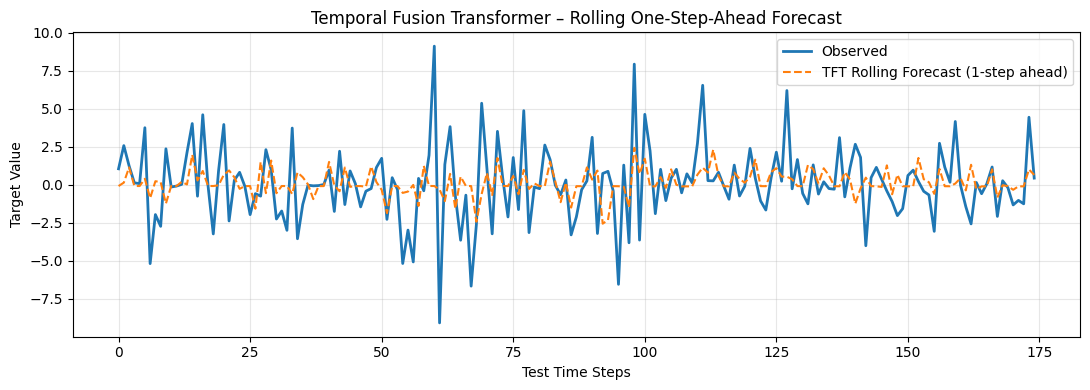

In [ ]:



min_len = min(len(y_true_daily), len(y_pred_daily))
y_true_plot = y_true_daily[:min_len]
y_pred_plot = y_pred_daily[:min_len]

plt.figure(figsize=(11, 4))

plt.plot(y_true_plot, label="Observed", linewidth=2)
plt.plot(y_pred_plot, label="TFT Rolling Forecast (1-step ahead)", linestyle="--")

plt.title("Temporal Fusion Transformer – Rolling One-Step-Ahead Forecast", fontsize=12)
plt.xlabel("Test Time Steps")
plt.ylabel("Target Value")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

        
rmse = np.sqrt(np.mean((y_true_daily - y_pred_daily)**2))

mae = np.mean(np.abs(y_true_daily - y_pred_daily))



direction_accuracy = np.mean(
    np.sign(y_true_daily) == np.sign(y_pred_daily)
)

print("RMSE:", rmse)
print("MAE:", mae)
print("Direction Accuracy:", direction_accuracy)


RMSE: 2.401545759985021
MAE: 1.7292605092150792
Direction Accuracy: 0.5942857142857143


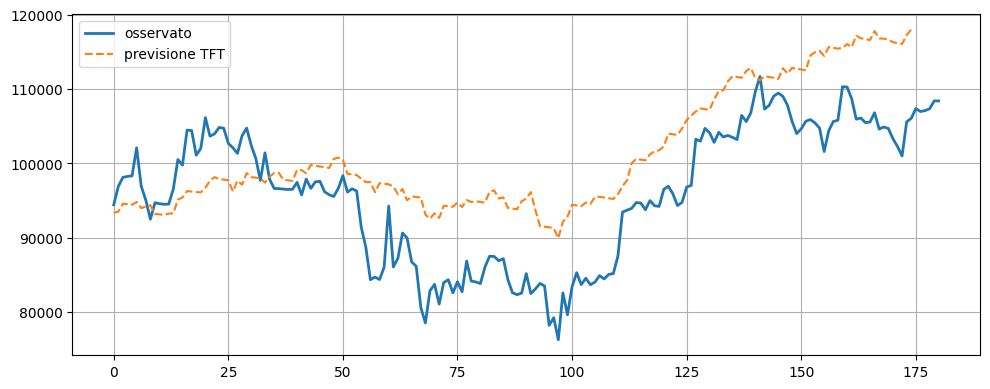

In [19]:


y_true = test_price["Bitcoin_Price"].values
initial_price = train_price["Bitcoin_Price"].iloc[-1] 
price_pred= returns_to_prices(y_pred_daily, initial_price)


plt.figure(figsize=(10, 4))
plt.plot(y_true, label="osservato", linewidth=2)
plt.plot(price_pred, label="previsione TFT", linestyle="--")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### Model Interpretation in Temporal Fusion Transformer (TFT)

One of the main strengths of the Temporal Fusion Transformer is its **built-in interpretability**.  
Unlike many deep learning models, TFT exposes internal attention weights and variable selection mechanisms that allow us to understand:

- Which variables are important
- When they are important
- Whether importance is static or time-dependent
- How the model allocates attention across past time steps

To access this information, we use:

- `predict(..., mode="raw")`
- `interpret_output(...)`
- `plot_interpretation(...)`

---

## 1) What does `mode="raw"` return?

When calling prediction with `mode="raw"`, the model does **not** return only the final forecasts.  

Instead, it returns a structured output containing:

- Predicted values
- Attention weights
- Variable selection weights
- Encoder and decoder contributions
- Additional intermediate tensors

This is fundamentally different from:

- `mode="prediction"` → returns only the final forecast values
- `mode="quantiles"` → returns predicted quantiles

`mode="raw"` exposes the internal components needed for interpretability.

It is important to clarify the difference between `mode="prediction"` and `mode="quantiles"`, especially when using `QuantileLoss()`.

With `QuantileLoss`, the model is trained to estimate multiple conditional quantiles of the future distribution (0.1, 0.5, 0.9).

- `mode="quantiles"` returns the full probabilistic output with shape:
  [n_windows, horizon, n_quantiles]

- `mode="prediction"` returns a single point forecast with shape:
  [n_windows, horizon]

Crucially, this point forecast is **not the average of the quantiles**.  
When using `QuantileLoss`, `mode="prediction"` returns the **median forecast (q = 0.5)**.

The median is used because in quantile regression it is the optimal estimator under L1 loss (MAE) and provides a robust central estimate.

In short:

- `prediction` → median (point forecast)  
- `quantiles` → full uncertainty distribution  
- `raw` → internal model components for interpretability


---

### What is inside the raw output?

The raw output typically includes:

#### 1. Predictions
The model’s predicted future values (possibly including quantiles, depending on the loss).

#### 2. Encoder attention weights
These show how much attention each historical time step receives when producing the forecast.

Interpretation:
- Higher weight → that past time step was more influential
- Lower weight → less relevant for prediction

This helps identify:
- Important historical events
- Seasonal dependencies
- Long-range vs short-range effects

---

#### 3. Variable selection weights (Static / Encoder / Decoder)

TFT contains **Variable Selection Networks (VSN)** at multiple levels:

- Static variable selection
- Encoder variable selection
- Decoder variable selection

These weights tell us:

- Which variables matter most overall
- Which variables matter during the historical encoding phase
- Which variables matter for forecasting future values

This is one of the most powerful interpretability features of TFT.

---

## 2) `interpret_output(...)`

The raw output is high-dimensional and window-based.

`interpret_output(...)` aggregates and restructures the raw tensors into a more interpretable format.

#### Two common reduction modes:

---

### `reduction="none"`

- Keeps interpretation per window
- Preserves local behavior
- Allows inspection of importance over time

Use this when you want:

- Window-level diagnostics
- Time-dependent analysis
- Investigation of specific prediction periods

Output shape:
- Contains interpretation values for each prediction window separately

---

### `reduction="mean"`

- Averages interpretation values across all windows
- Produces global importance summaries

Use this when you want:

- Overall variable importance
- Average attention behavior
- High-level model explanation

This is the most common choice for a tutorial because it provides a clear global summary.

---

## 3) `plot_interpretation(...)`

This function visualizes:

- Static variable importance
- Encoder variable importance
- Decoder variable importance
- Attention over time

The resulting plots typically show:

- Bar charts for variable importance
- Attention curves across encoder positions

This provides immediate visual insight into:

- Which covariates drive the forecast
- Whether the model relies more on recent or distant history
- Whether static features influence predictions

---

## 4) How to fully leverage `mode="raw"`

Using `raw` output allows you to:

#### Analyze temporal attention patterns
- Detect seasonality reliance
- Identify structural breaks
- Evaluate long-memory effects

#### Compare feature importance across windows
- Study regime shifts
- Detect changing economic drivers
- Evaluate stability of feature influence

#### Debug the model
- Identify if the model is ignoring key covariates
- Detect over-reliance on short-term signals
- Verify that known-future variables are actually used

---

## 5) Conceptual Summary

Standard prediction mode answers:

"What will happen?"

Raw mode answers:

"Why does the model think this will happen?"

It exposes the internal decision mechanisms of TFT and transforms it from a black box into a semi-transparent forecasting system.

This interpretability capability is one of the key innovations of the original TFT architecture and one of the reasons it is widely used in applied time series forecasting.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x400 with 1 Axes>,
 'decoder_variables': <Figure size 700x375 with 1 Axes>}

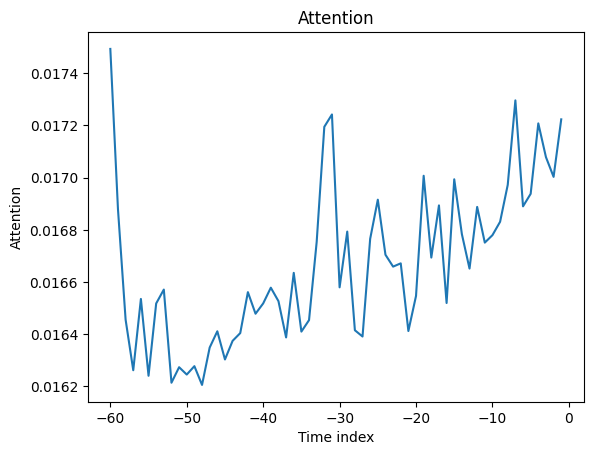

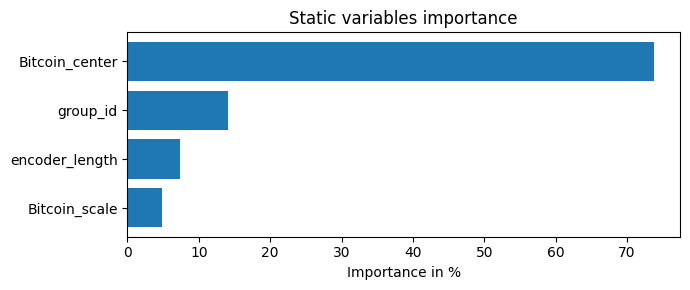

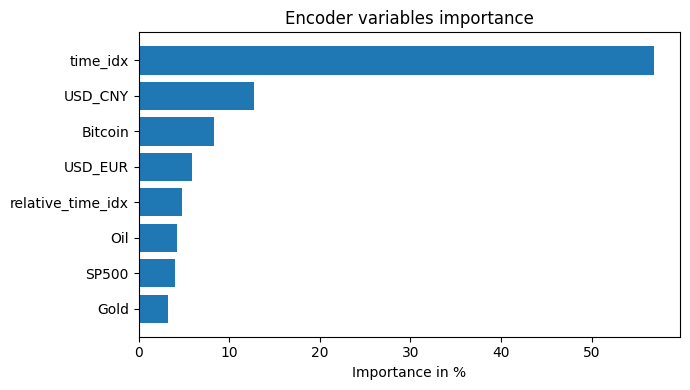

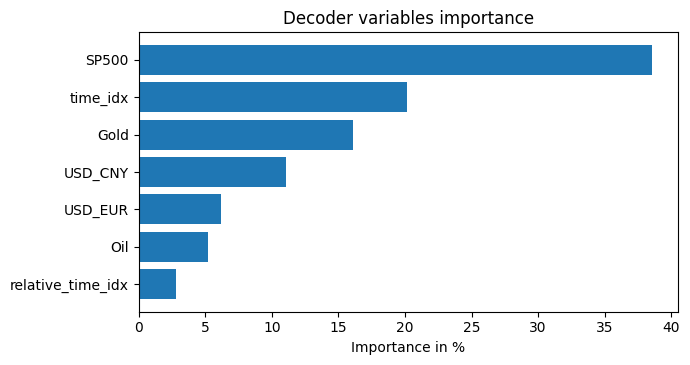

In [20]:
set_seed_all(seed)
raw = tft.predict(test_loader, mode="raw")
interpretation = tft.interpret_output(raw, reduction="none")
interpret_mean = tft.interpret_output(raw, reduction="mean")
# plot (mostra subito)
tft.plot_interpretation(interpret_mean)

# TFT – Probabilistic Forecasting with Quantile Outputs

In [25]:

target_col = return_data.columns[0]
covariates = ["Gold", "Oil", "SP500", "USD_CNY", "USD_EUR"]

split_date = "2024-12-31"
training_cutoff = return_data.loc[:split_date, "time_idx"].max()
first_test_idx = training_cutoff + 1

encoder_length = 60
h = 7  # horizon

seed = 7
hidden_size = 16
attention_head_size = 1
dropout = 0.2
learning_rate = 1e-3
max_epochs = 5
batch_size = 64
precision = "32-true"
num_workers = 0

# NEW: quantiles for probabilistic forecasting 
quantiles = [0.1, 0.5, 0.9]   


In [28]:
from sklearn.preprocessing import StandardScaler
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

scalers = {c: StandardScaler() for c in covariates}

set_seed_all(seed)

training_dataset = TimeSeriesDataSet(
    train,
    time_idx="time_idx",
    target=target_col,
    group_ids=["group_id"],
    max_encoder_length=encoder_length,
    max_prediction_length=h,
    static_categoricals=["group_id"],
    time_varying_known_reals=["time_idx"] + covariates,
    time_varying_unknown_reals=[target_col],
    target_normalizer=GroupNormalizer(groups=["group_id"]),
    scalers=scalers,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data=return_data,
    predict=False,              # rolling / backtesting
    min_prediction_idx=first_test_idx,
    stop_randomization=True,
)

test_loader = test_dataset.to_dataloader(
    train=False,
    batch_size=64,
    num_workers=0
)


In [32]:

set_seed_all(seed)
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=learning_rate,
    hidden_size=hidden_size,
    attention_head_size=attention_head_size,
    dropout=dropout,
    loss=QuantileLoss(quantiles=quantiles),  # Put here the quantiles list!
)

trainer = L.Trainer(
    max_epochs=max_epochs,
    gradient_clip_val=0.1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision=precision,
    deterministic=False,
    enable_checkpointing=True,
)

train_loader = training_dataset.to_dataloader(train=True, batch_size=64, num_workers=0, pin_memory=True)
trainer.fit(tft, train_dataloaders=train_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1      | train
3  | prescalers                         | ModuleDict                      | 176    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 1.8 K  |

Epoch 4: 100%|██████████| 48/48 [00:07<00:00,  6.03it/s, v_num=149, train_loss_step=1.530, train_loss_epoch=1.650]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 48/48 [00:08<00:00,  5.88it/s, v_num=149, train_loss_step=1.530, train_loss_epoch=1.650]


### Change in Prediction Step (Point Forecast → Quantile Forecast)

Previously, the model was called with `mode="prediction"`, which returns a single point forecast for each horizon step (typically the median/expected prediction) with shape `[n_windows, h]`. The code then extracted the first step ahead to obtain a rolling one-day forecast.

Now the model is called with `mode="quantiles"`, which returns multiple conditional quantile forecasts instead of a single value. The output has shape `[n_windows, h, n_quantiles]`, where the last dimension corresponds to the requested quantile levels (e.g., 0.1, 0.5, 0.9).
This allows us to extract:

* a lower bound (e.g., 10th percentile),
* the median forecast (50th percentile),
* an upper bound (e.g., 90th percentile),

for the same one-step-ahead horizon.

In short, the prediction step moves from **deterministic forecasting** (one value per time step) to **probabilistic forecasting** (a distribution summarized by quantiles), enabling uncertainty estimation and prediction intervals.


In [33]:

# get quantile predictions for the test set using the trained model: shape: [n_windows, h, n_quantiles]
pred = tft.predict(test_loader, mode="quantiles")

pred = pred.detach().cpu().numpy()

# 1-step ahead
q10 = pred[:, 0, 0]
q50 = pred[:, 0, 1]
q90 = pred[:, 0, 2]

# ground truth allineata
y_true_daily = return_data.loc[
    return_data.time_idx >= first_test_idx, target_col
].values[: len(q50)]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


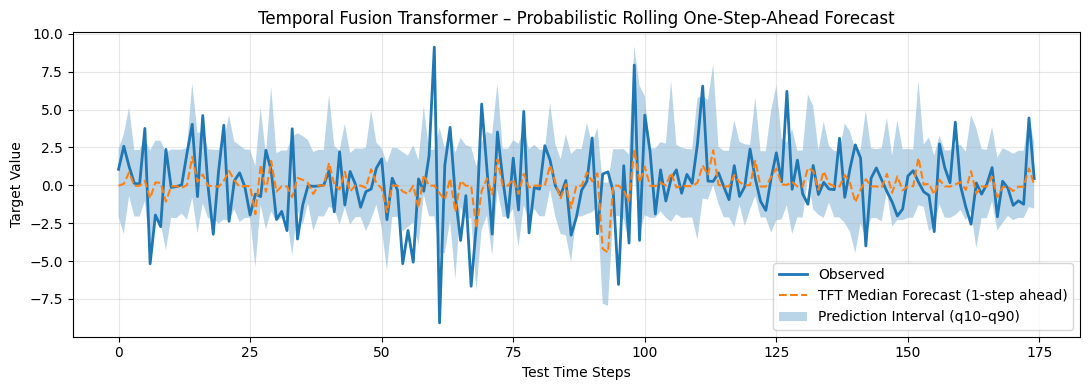

In [ ]:


min_len = min(len(y_true_daily), len(q50))

y_true_plot = y_true_daily[:min_len]
q10_plot = q10[:min_len]
q50_plot = q50[:min_len]
q90_plot = q90[:min_len]

plt.figure(figsize=(11, 4))

plt.plot(y_true_plot, label="Observed", linewidth=2)
plt.plot(q50_plot, label="TFT Median Forecast (1-step ahead)", linestyle="--")

plt.fill_between(
    range(min_len),
    q10_plot,
    q90_plot,
    alpha=0.3,
    label="Prediction Interval (q10–q90)"
)

plt.title("Temporal Fusion Transformer – Probabilistic Rolling One-Step-Ahead Forecast", fontsize=12)
plt.xlabel("Test Time Steps")
plt.ylabel("Target Value")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

        
rmse = np.sqrt(np.mean((y_true_daily - q50)**2))
mae = np.mean(np.abs(y_true_daily - q50))

direction_accuracy = np.mean(
    np.sign(y_true_daily) == np.sign(q50)
)

print("RMSE:", rmse)
print("MAE:", mae)
print("Direction Accuracy:", direction_accuracy)


RMSE: 2.4397457594359873
MAE: 1.7549570895532238
Direction Accuracy: 0.5885714285714285


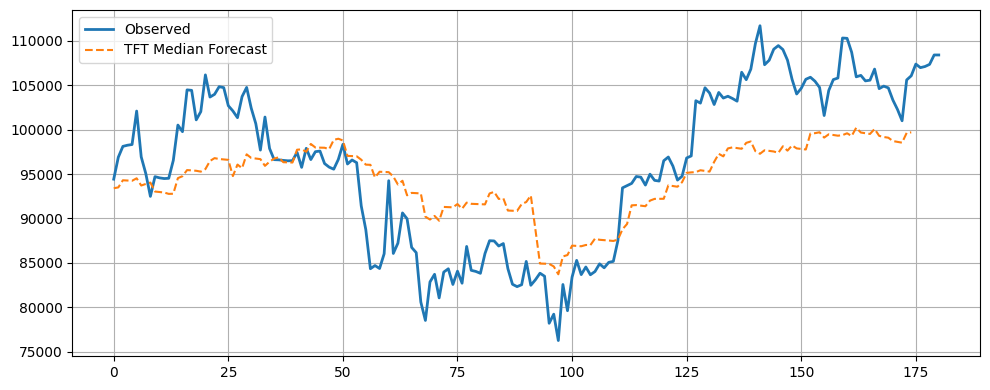

In [36]:
y_true = test_price["Bitcoin_Price"].values
initial_price = train_price["Bitcoin_Price"].iloc[-1]

price_pred = returns_to_prices(q50, initial_price)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label="Observed", linewidth=2)
plt.plot(price_pred, label="TFT Median Forecast", linestyle="--")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Extracting Forecasts for Each Horizon from the TFT Quantile Output

The Temporal Fusion Transformer returns probabilistic forecasts in a 3-dimensional array with shape **[N, H, Q]**, where:

* **N** = number of rolling prediction windows
* **H** = forecast horizon (number of future steps predicted for each window)
* **Q** = number of quantiles (e.g., q10, q50, q90)

Each element `pred_q[i, h, q]` represents the predicted value:

* for window **i**
* at horizon step **h** (0 = 1-step ahead, 1 = 2-steps ahead, …)
* for quantile **q**

To extract forecasts for a specific horizon:

* Select the horizon index along the second dimension

  * `h = 0` → 1-step ahead forecasts
  * `h = 2` → 3-steps ahead forecasts
  * `h = 4` → 5-steps ahead forecasts

For that chosen horizon:

* `pred_q[:, h, 0]` gives the lower quantile (e.g., 10th percentile)
* `pred_q[:, h, 1]` gives the median forecast (50th percentile)
* `pred_q[:, h, 2]` gives the upper quantile (e.g., 90th percentile)

Because predictions are generated using rolling windows, the forecast at window **i** and horizon **h** corresponds to the real observation at time index:

**time_idx = first_test_idx + i + h**

This alignment is what allows us to:

1. Build the matrix of true values for each horizon
2. Compute metrics separately per horizon
3. Plot forecasts and uncertainty bands for different forecast distances

In summary, extracting forecasts per horizon simply means selecting the appropriate slice of the prediction tensor along the **horizon dimension**, then aligning it with the corresponding future timestamps.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Coverage q10–q90 by horizon: [0.754 0.749 0.754 0.754 0.76  0.76  0.766]
Avg interval width by horizon: [5.4507 5.4867 5.4911 5.4854 5.4833 5.4774 5.4717]
RMSE (q50) by horizon: [2.4397 2.4363 2.4296 2.4301 2.4299 2.4306 2.417 ]
MAE  (q50) by horizon: [1.755  1.754  1.7441 1.7431 1.7436 1.7483 1.7292]


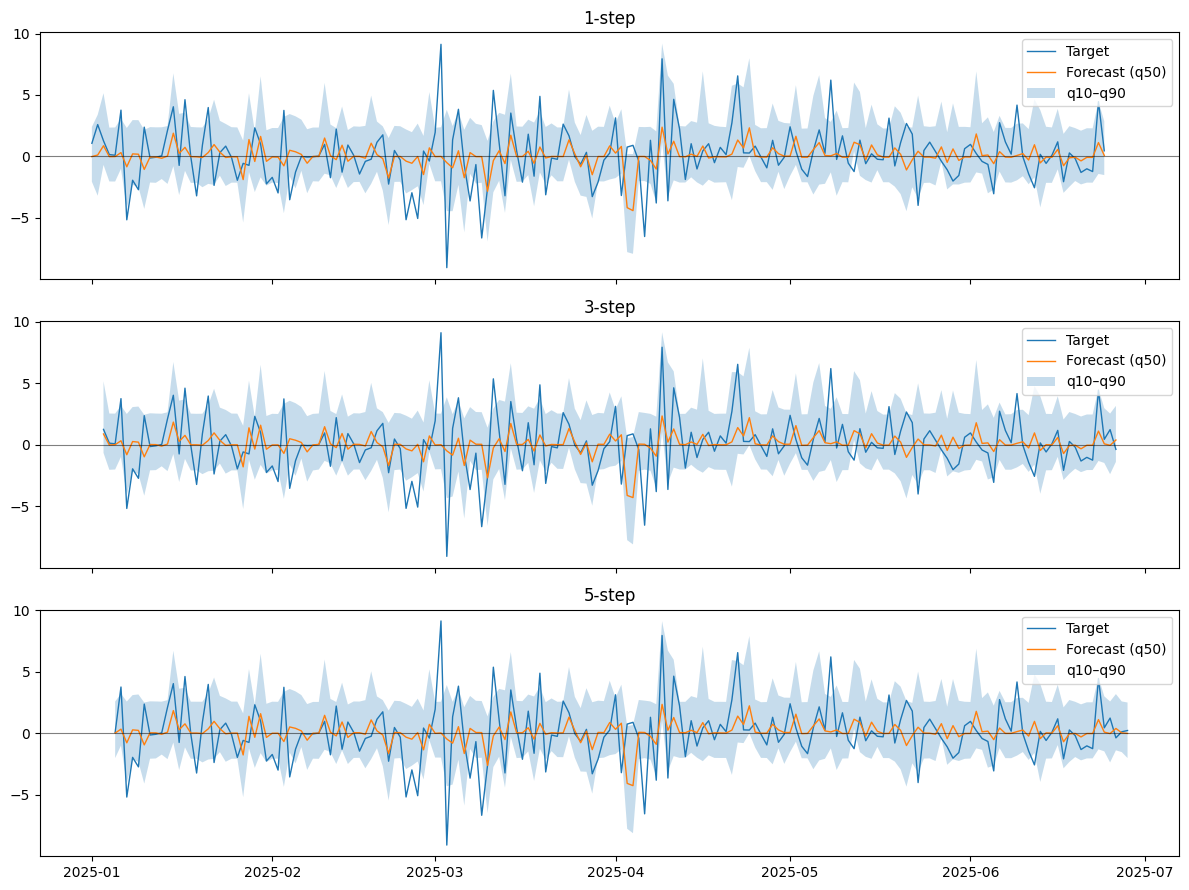

In [ ]:


# 1) Get FULL quantile forecasts for the whole horizon 
# shape: [N, H, Q] where Q=len(quantiles)=3 (q10,q50,q90)
pred_q = tft.predict(test_loader, mode="quantiles").detach().cpu().numpy()

q10_all = pred_q[:, :, 0]
q50_all = pred_q[:, :, 1]
q90_all = pred_q[:, :, 2]

# 2) Build y_true matrix aligned to the rolling windows (same shape [N,H]) 
# For rolling windows with stride=1, the true value for window i at horizon k
# corresponds to target at time_idx = first_test_idx + i + k
N = pred_q.shape[0]
H = pred_q.shape[1]

start_pos = int(first_test_idx)
end_pos = start_pos + N + H - 1  # exclusive upper bound for slicing
y_seq = return_data.loc[return_data.time_idx >= start_pos, target_col].values[: (N + H - 1)]

y_true_mat = np.stack([y_seq[k:k+N] for k in range(H)], axis=1)  # [N,H]

# 3) Probabilistic metrics: coverage + interval width (per horizon) 
coverage_h = np.mean((y_true_mat >= q10_all) & (y_true_mat <= q90_all), axis=0)  # [H]
width_h = np.mean(q90_all - q10_all, axis=0)                                     # [H]

print("Coverage q10–q90 by horizon:", np.round(coverage_h, 3))
print("Avg interval width by horizon:", np.round(width_h, 4))


rmse_h = np.sqrt(np.mean((y_true_mat - q50_all) ** 2, axis=0))
mae_h = np.mean(np.abs(y_true_mat - q50_all), axis=0)

print("RMSE (q50) by horizon:", np.round(rmse_h, 4))
print("MAE  (q50) by horizon:", np.round(mae_h, 4))

# 4) Multi-horizon plot (1,3,5-step) with dates + quantile bands 
hs = [0, 2, 4]  # 1,3,5-step ahead
titles = ["1-step", "3-step", "5-step"]


time_to_date = (
    return_data
    .reset_index()
    .set_index("time_idx")["Date"]
)

# decoder time_idx for each window/horizon
# for window i (0..N-1) and horizon k (0..H-1): time_idx = first_test_idx + i + k
time_idx_mat = (start_pos + np.arange(N)[:, None] + np.arange(H)[None, :]).astype(int)  # [N,H]

fig, axes = plt.subplots(len(hs), 1, figsize=(12, 9), sharex=True)

for ax, hh, ttl in zip(axes, hs, titles):
    tmp = pd.DataFrame({
        "time_idx": time_idx_mat[:, hh],
        "y_true": y_true_mat[:, hh],
        "q10": q10_all[:, hh],
        "q50": q50_all[:, hh],
        "q90": q90_all[:, hh],
    }).sort_values("time_idx")

    tmp["date"] = pd.to_datetime(time_to_date.loc[tmp["time_idx"]].values)

    ax.plot(tmp["date"], tmp["y_true"], label="Target", linewidth=1.0)
    ax.plot(tmp["date"], tmp["q50"], label="Forecast (q50)", linewidth=1.0)
    ax.fill_between(tmp["date"], tmp["q10"], tmp["q90"], alpha=0.25, label="q10–q90")

    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title(ttl)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x400 with 1 Axes>,
 'decoder_variables': <Figure size 700x375 with 1 Axes>}

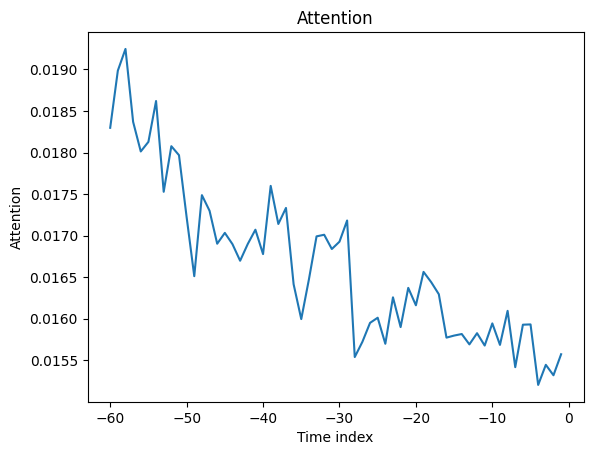

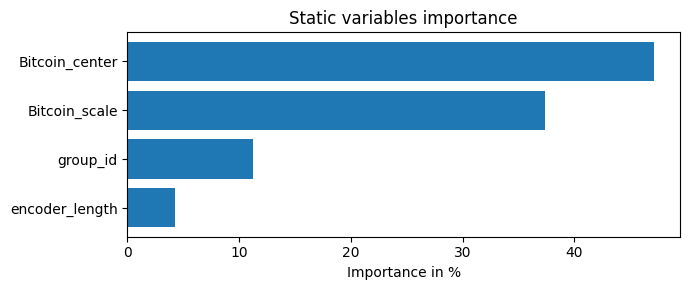

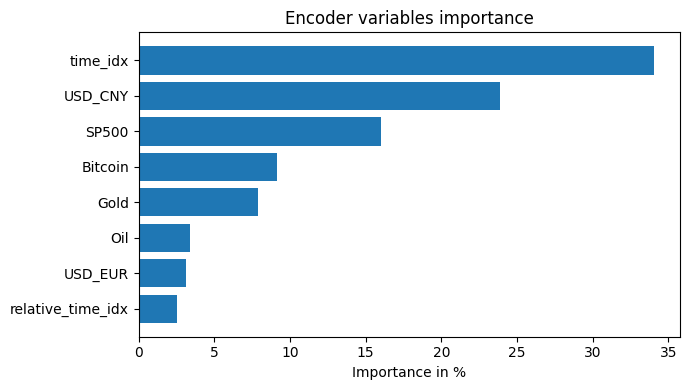

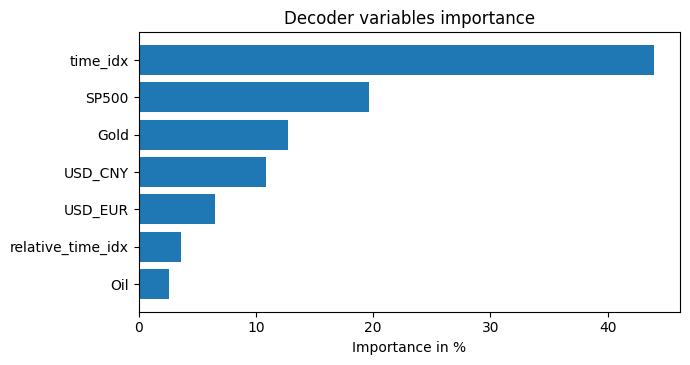

In [41]:
set_seed_all(seed)
raw = tft.predict(test_loader, mode="raw")
interpretation = tft.interpret_output(raw, reduction="none")
interpret_mean = tft.interpret_output(raw, reduction="mean")
tft.plot_interpretation(interpret_mean)

# Probabilistic Validation (Quantile TFT)

## Adding a Validation Set (Rolling) and Selecting the Best TFT Checkpoint

Compared to the previous “train + test only” setup, this version introduces a **third split**: a **validation set** used exclusively to guide training decisions (early stopping, best checkpoint selection). The test set remains untouched until the very end.

---

# 1) What changes compared to the previous code?

### Before (no validation)
- The model was trained on the full training period.
- Evaluation was performed only on the test period.
- Model selection implicitly used the **final epoch**, even if the model started to overfit.

### Now (with validation)
- The original training period is split into:
  - `train2` (new training set)
  - `val` (validation set)
- The **validation set is not used for weight updates**, only for monitoring generalization.
- The model checkpoint with the **best validation loss** is selected automatically.

This is the standard workflow for robust model selection.

---

# 2) How the validation set is created in our code

We create the validation set by taking a block from the **end of the training period**, with the **same length as the test set**:

- `T = len(test)`  
- `val = train.tail(T)`  
- `train2 = train.iloc[:-T]`

Intuition:
- validation is chosen to be “recent”, so it resembles the test regime
- using the same length as test makes the split symmetric and easy to explain

Then we overwrite:

- `train = train2`

so the rest of the pipeline can be reused with minimal changes.

---

# 3) Rolling validation: why it’s different from a simple holdout

Instead of validating on a single window, you use a **rolling / backtesting validation**:

- `min_prediction_idx = val_start` forces predictions to start at the first validation time index
- `predict=False` generates **many rolling windows**
- `stop_randomization=True` ensures deterministic sliding windows

This produces a validation evaluation that is closer to real deployment:
the model is repeatedly tested as time moves forward.

---

# 4) Why `val_data` includes history before the validation period

Validation windows require an encoder context of length `max_encoder_length`.

For that reason, you build:

- `val_data = return_data[time_idx <= val_end]`

So validation has access to:
- all past history needed by the encoder
- while predictions start only at `val_start`

This is a standard pattern when creating rolling validation sets.

---

# 5) What adding a validation set changes in training behavior

With a validation set, you can:

- Detect overfitting (val loss stops improving while train loss improves)
- Tune hyperparameters objectively
- Use early stopping to stop training at the right moment
- Select the best model checkpoint

This makes results more stable and more reproducible than relying on the last epoch.

---

# 6) How `best_tft` is determined

Two Lightning callbacks drive model selection:

### ModelCheckpoint
- Monitors `val_loss`
- Saves the checkpoint with the minimum validation loss (`mode="min"`)
- Keeps only the best model (`save_top_k=1`)

As training progresses, whenever validation improves, the current model is saved as the new best checkpoint.

### EarlyStopping
- Monitors `val_loss`
- Stops training if `val_loss` does not improve for `patience` epochs

This prevents wasting epochs once the model stops generalizing better.

---

# 7) Loading the best model (`best_tft`)

After training ends (either by reaching max epochs or early stopping), you load:

- the checkpoint path stored by ModelCheckpoint
- the corresponding saved weights

This gives:

- `best_tft`: the model that achieved the **lowest validation loss**
- not necessarily the final epoch model

This is the correct model to use for test evaluation.

---

# 8) Final test prediction remains out-of-sample

Only after selecting `best_tft` do you run predictions on the test loader.

This preserves a clean experimental protocol:

- Train on `train2`
- Select on `val`
- Report performance on `test`

This is the most standard and defensible setup for a tutorial and for real forecasting experiments.


In [44]:
# Let's add a validation set with the same length as the test set, taken from the end of the training period.
train = return_data.loc[:split_date].copy()
test  = return_data.loc[split_date:].copy()          

#test = return_data.loc[return_data.time_idx >= first_test_idx].copy()

T = len(test)
val = train.tail(T).copy()
train2 = train.iloc[:-T].copy()

print("len(train2):", len(train2))
print("len(val):", len(val))
print("len(test):", len(test))

# call train2 as train from now on, so the rest of the code can be reused without changes
train = train2


len(train2): 2986
len(val): 182
len(test): 182


In [45]:
encoder_length=60
seed=7
hidden_size=16
attention_head_size=1
dropout=0.2
learning_rate=1e-3
max_epochs=5
batch_size=64
precision="32-true"
num_workers=0

encoder_length = 60
h = 7  # HORIZON (h=7 days)

In [ ]:
scalers = {c: StandardScaler() for c in covariates}

set_seed_all(seed)
training_dataset = TimeSeriesDataSet(
    train,
    time_idx="time_idx",
    target=target_col,
    group_ids=["group_id"],
    max_encoder_length=encoder_length,
    max_prediction_length=h,
    static_categoricals=["group_id"],
    time_varying_known_reals=["time_idx"] + covariates,
    time_varying_unknown_reals=[target_col],
    target_normalizer=GroupNormalizer(groups=["group_id"]),
    scalers=scalers,                 
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)


# validation rolling
val_start = val["time_idx"].min()
val_end   = val["time_idx"].max()
val_data = return_data[return_data["time_idx"] <= val_end].copy()

val_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data=val_data,
    predict=False,                 # rolling validation
    min_prediction_idx=val_start,
    stop_randomization=True,
)


train_loader = training_dataset.to_dataloader(train=True, batch_size=batch_size, num_workers=num_workers, pin_memory=True)
val_loader   = val_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=num_workers, pin_memory=True)


test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data=return_data,
    predict = False, #default: for ROLLING/BACK TESTING
    min_prediction_idx=first_test_idx,
    stop_randomization=True,
)

test_loader = test_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)




In [ ]:
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

set_seed_all(seed)
quantiles = [0.1, 0.5, 0.9]

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=learning_rate,
    hidden_size=hidden_size,
    attention_head_size=attention_head_size,
    dropout=dropout,
    loss=QuantileLoss(quantiles=quantiles),
)

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-tft",
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
)

logger = CSVLogger("logs", name="tft_run")

trainer = L.Trainer(
    max_epochs=max_epochs,
    gradient_clip_val=0.1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision=precision,
    callbacks=[checkpoint_cb, earlystop_cb],
    logger=logger,
    enable_checkpointing=True,
)

train_loader = training_dataset.to_dataloader(
    train=True, batch_size=batch_size, num_workers=num_workers, pin_memory=True
)
val_loader = val_dataset.to_dataloader(
    train=False, batch_size=batch_size, num_workers=num_workers, pin_memory=True
)

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

# load the best model according to validation loss
best_tft = TemporalFusionTransformer.load_from_checkpoint(checkpoint_cb.best_model_path)

# get quantile predictions for the test set using the trained model: shape: [n_windows, h, n_quantiles]
pred_q = best_tft.predict(test_loader, mode="quantiles").detach().cpu().numpy()
y_pred_daily = pred_q[:, 0, 1]  # q50, 1-step ahead

y_true_daily = return_data.loc[
    return_data.time_idx >= first_test_idx, target_col
].values[: len(y_pred_daily)]
print("Best checkpoint:", checkpoint_cb.best_model_path)
print("Best val_loss:", checkpoint_cb.best_model_score)
print("Best epoch:", checkpoint_cb.best_model_path.split("epoch=")[-1].split("-")[0] if "epoch=" in checkpoint_cb.best_model_path else "unknown")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1      | train
3  | prescalers                         | ModuleDict                      | 176    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 1.8 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 5.1 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 4.4 K  | train
7  | static_cont

Epoch 4: 100%|██████████| 45/45 [00:09<00:00,  4.74it/s, v_num=1, train_loss_step=1.630, val_loss=1.230, train_loss_epoch=1.680]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 45/45 [00:09<00:00,  4.62it/s, v_num=1, train_loss_step=1.630, val_loss=1.230, train_loss_epoch=1.680]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Best checkpoint: logs\tft_run\version_1\checkpoints\best-tft.ckpt
Best val_loss: tensor(1.2263, device='cuda:0')
Best epoch: unknown


In [57]:
import torch

ckpt_path = checkpoint_cb.best_model_path
print("Best checkpoint:", ckpt_path)

best_tft = TemporalFusionTransformer.load_from_checkpoint(ckpt_path)

ckpt = torch.load(ckpt_path, map_location="cpu")

print("Best epoch:", ckpt.get("epoch"))
print("Global step:", ckpt.get("global_step"))


Best checkpoint: logs\tft_run\version_1\checkpoints\best-tft.ckpt
Best epoch: 4
Global step: 225


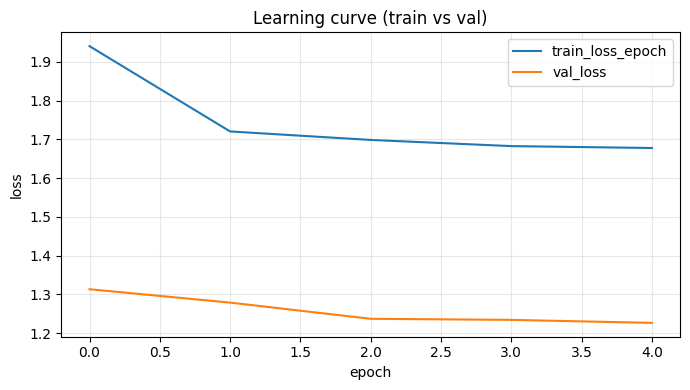

In [ ]:

metrics_path = trainer.logger.log_dir + "/metrics.csv"
dfm = pd.read_csv(metrics_path)

train_df = (
    dfm[dfm["train_loss_epoch"].notna()][["epoch", "train_loss_epoch"]]
    .groupby("epoch").last()
)

val_df = (
    dfm[dfm["val_loss"].notna()][["epoch", "val_loss"]]
    .groupby("epoch").last()
)

plt.figure(figsize=(7,4))
plt.plot(train_df.index, train_df["train_loss_epoch"], label="train_loss_epoch")
plt.plot(val_df.index, val_df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Learning curve (train vs val)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
# get quantile predictions for the test set using the BEST trained model
# shape: [n_windows, h, n_quantiles]
pred = best_tft.predict(test_loader, mode="quantiles")

pred = pred.detach().cpu().numpy()

# 1-step ahead
q10 = pred[:, 0, 0]
q50 = pred[:, 0, 1]
q90 = pred[:, 0, 2]

# aligned ground truth
y_true_daily = return_data.loc[
    return_data.time_idx >= first_test_idx, target_col
].values[:len(q50)]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


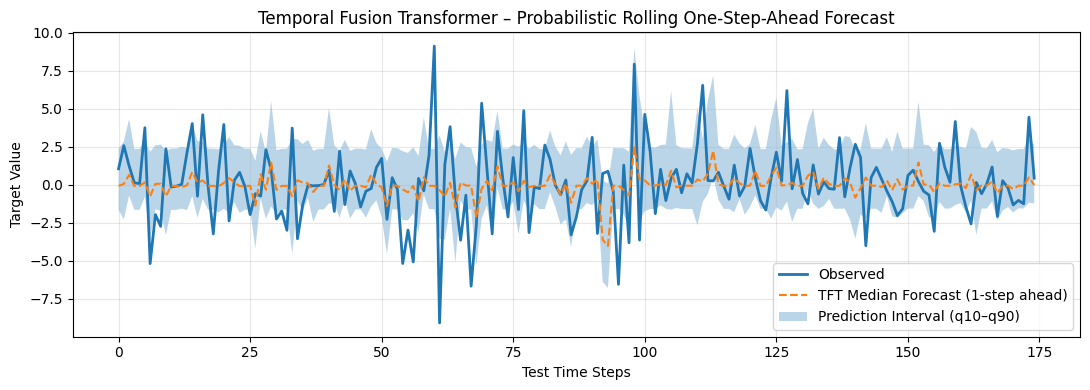

In [ ]:

min_len = min(len(y_true_daily), len(q50))

y_true_plot = y_true_daily[:min_len]
q10_plot = q10[:min_len]
q50_plot = q50[:min_len]
q90_plot = q90[:min_len]

plt.figure(figsize=(11, 4))

plt.plot(y_true_plot, label="Observed", linewidth=2)
plt.plot(q50_plot, label="TFT Median Forecast (1-step ahead)", linestyle="--")

plt.fill_between(
    range(min_len),
    q10_plot,
    q90_plot,
    alpha=0.3,
    label="Prediction Interval (q10–q90)"
)

plt.title("Temporal Fusion Transformer – Probabilistic Rolling One-Step-Ahead Forecast", fontsize=12)
plt.xlabel("Test Time Steps")
plt.ylabel("Target Value")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

        
rmse = np.sqrt(np.mean((y_true_daily - q50)**2))
mae = np.mean(np.abs(y_true_daily - q50))

direction_accuracy = np.mean(
    np.sign(y_true_daily) == np.sign(q50)
)

coverage = np.mean((y_true_daily >= q10) & (y_true_daily <= q90))
avg_width = np.mean(q90 - q10)

print("RMSE:", rmse)
print("MAE:", mae)
print("Direction Accuracy:", direction_accuracy)
print("Coverage (q10–q90):", coverage)
print("Avg interval width:", avg_width)


RMSE: 2.4597731540230323
MAE: 1.7527738454914823
Direction Accuracy: 0.5714285714285714
Coverage (q10–q90): 0.6857142857142857
Avg interval width: 4.594913


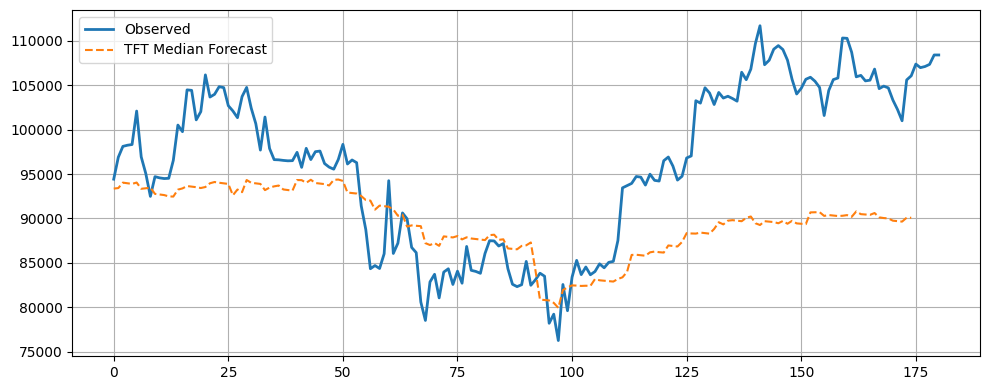

In [63]:
y_true = test_price["Bitcoin_Price"].values
initial_price = train_price["Bitcoin_Price"].iloc[-1]

price_pred = returns_to_prices(q50, initial_price)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label="Observed", linewidth=2)
plt.plot(price_pred, label="TFT Median Forecast", linestyle="--")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Coverage q10–q90 by horizon: [0.686 0.697 0.697 0.714 0.714 0.714 0.726]
Avg interval width by horizon: [4.5949 4.6278 4.6812 4.7242 4.7561 4.7742 4.785 ]
RMSE (q50) by horizon: [2.4598 2.4591 2.4517 2.4506 2.4502 2.4512 2.4363]
MAE  (q50) by horizon: [1.7528 1.754  1.7436 1.7408 1.7408 1.7456 1.7251]


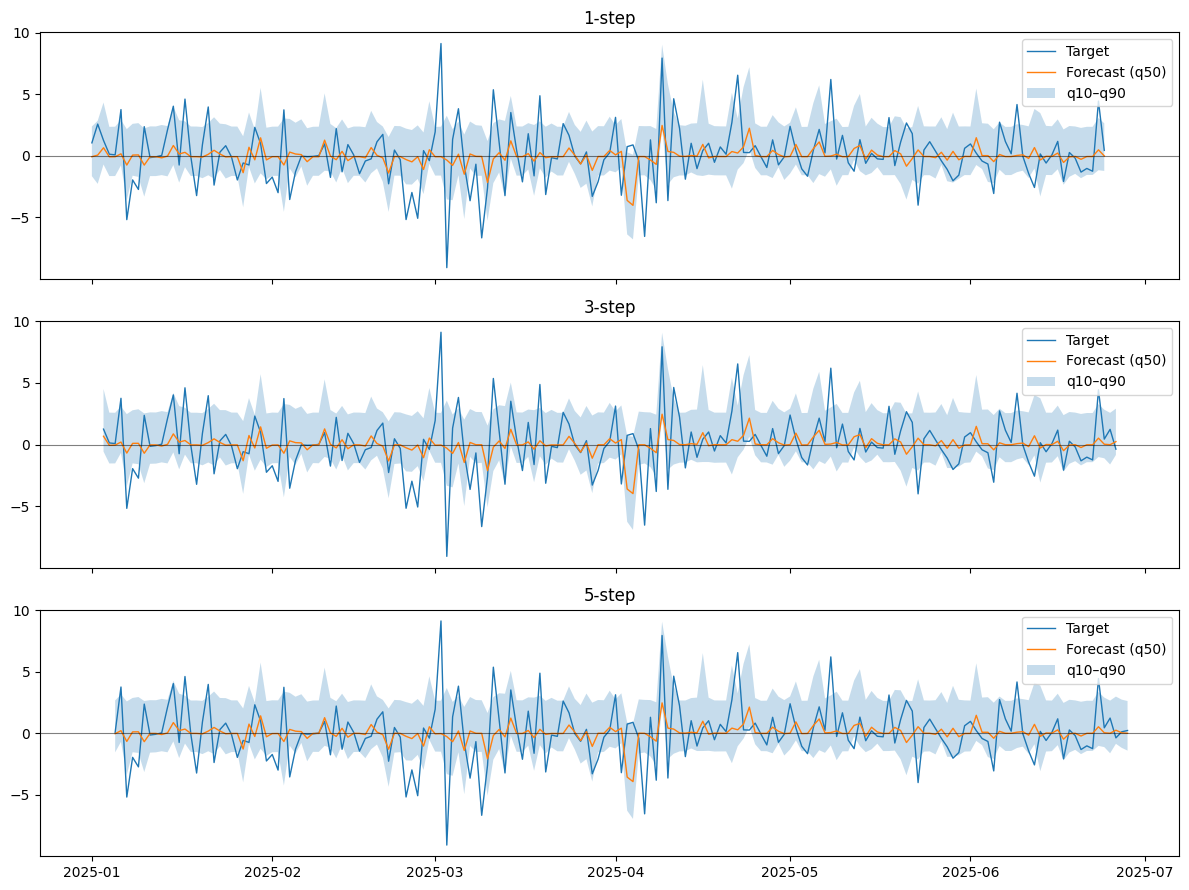

In [ ]:

# AFTER THE LAST PRICE PLOT: quantile-based (probabilistic) eval + multi-horizon plots
# Assumes you already computed pred_q = tft.predict(test_loader, mode="quantiles")
# OR recompute it here safely.


# 1) Get FULL quantile forecasts for the whole horizon 
# shape: [N, H, Q] where Q=len(quantiles)=3 (q10,q50,q90)
pred_q = best_tft.predict(test_loader, mode="quantiles").detach().cpu().numpy()

q10_all = pred_q[:, :, 0]
q50_all = pred_q[:, :, 1]
q90_all = pred_q[:, :, 2]

# 2) Build y_true matrix aligned to the rolling windows (same shape [N,H]) 
# For rolling windows with stride=1, the true value for window i at horizon k
# corresponds to target at time_idx = first_test_idx + i + k
N = pred_q.shape[0]
H = pred_q.shape[1]

start_pos = int(first_test_idx)
end_pos = start_pos + N + H - 1  # exclusive upper bound for slicing
y_seq = return_data.loc[return_data.time_idx >= start_pos, target_col].values[: (N + H - 1)]

y_true_mat = np.stack([y_seq[k:k+N] for k in range(H)], axis=1)  # [N,H]

# 3) Probabilistic metrics: coverage + interval width (per horizon) ---
coverage_h = np.mean((y_true_mat >= q10_all) & (y_true_mat <= q90_all), axis=0)  # [H]
width_h = np.mean(q90_all - q10_all, axis=0)                                     # [H]

print("Coverage q10–q90 by horizon:", np.round(coverage_h, 3))
print("Avg interval width by horizon:", np.round(width_h, 4))


rmse_h = np.sqrt(np.mean((y_true_mat - q50_all) ** 2, axis=0))
mae_h = np.mean(np.abs(y_true_mat - q50_all), axis=0)

print("RMSE (q50) by horizon:", np.round(rmse_h, 4))
print("MAE  (q50) by horizon:", np.round(mae_h, 4))

# 4) Multi-horizon plot (1,3,5-step) with dates + quantile bands 
hs = [0, 2, 4]  # 1,3,5-step ahead
titles = ["1-step", "3-step", "5-step"]

# mapping time_idx -> Date (unique)
time_to_date = (
    return_data
    .reset_index()
    .set_index("time_idx")["Date"]
)

# decoder time_idx for each window/horizon
# for window i (0..N-1) and horizon k (0..H-1): time_idx = first_test_idx + i + k
time_idx_mat = (start_pos + np.arange(N)[:, None] + np.arange(H)[None, :]).astype(int)  # [N,H]

fig, axes = plt.subplots(len(hs), 1, figsize=(12, 9), sharex=True)

for ax, hh, ttl in zip(axes, hs, titles):
    tmp = pd.DataFrame({
        "time_idx": time_idx_mat[:, hh],
        "y_true": y_true_mat[:, hh],
        "q10": q10_all[:, hh],
        "q50": q50_all[:, hh],
        "q90": q90_all[:, hh],
    }).sort_values("time_idx")

    tmp["date"] = pd.to_datetime(time_to_date.loc[tmp["time_idx"]].values)

    ax.plot(tmp["date"], tmp["y_true"], label="Target", linewidth=1.0)
    ax.plot(tmp["date"], tmp["q50"], label="Forecast (q50)", linewidth=1.0)
    ax.fill_between(tmp["date"], tmp["q10"], tmp["q90"], alpha=0.25, label="q10–q90")

    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title(ttl)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x400 with 1 Axes>,
 'decoder_variables': <Figure size 700x375 with 1 Axes>}

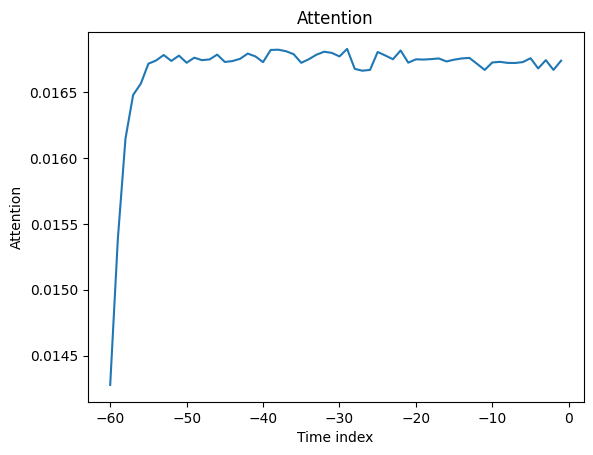

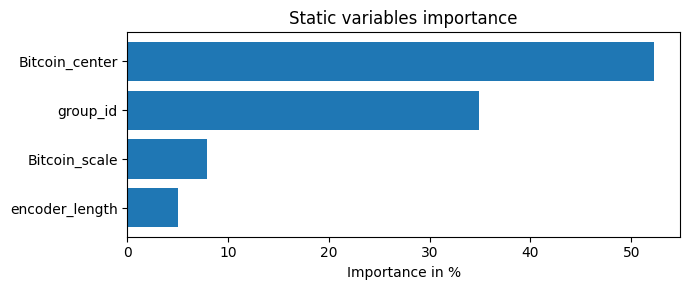

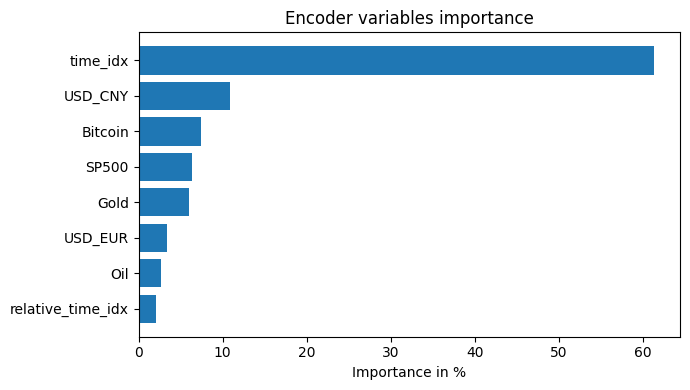

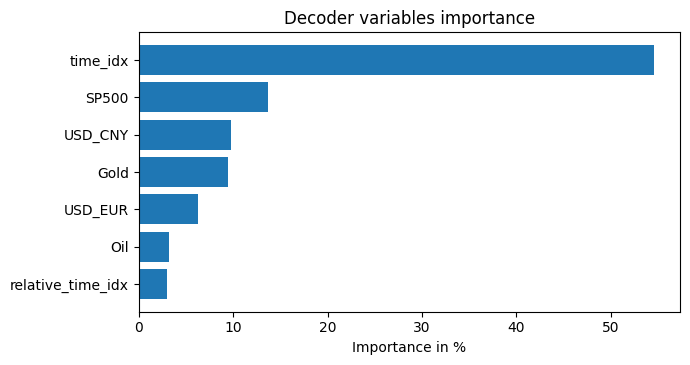

In [65]:
set_seed_all(seed)
raw = best_tft.predict(test_loader, mode="raw")
interpretation = best_tft.interpret_output(raw, reduction="none")
interpret_mean = best_tft.interpret_output(raw, reduction="mean")
best_tft.plot_interpretation(interpret_mean)